# StreamLoop — Customer Churn Exploratory Data Analysis

StreamLoop's customer data is publicly modeled after the well-known **IBM Telco Customer Churn** dataset. This notebook follows a simple, step-by-step EDA workflow: import libraries → load data → analyze → prepare → visualize → build a baseline model.

**Target:** `Churn` (`Yes` / `No`) — did the customer leave. The remaining columns are customer *account*, *service*, and *billing* attributes.

## Step 1: Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## Step 2: Load the dataset

We load StreamLoop's churn data **directly from the public URL** — no manual download needed.

- **Target:** `Churn` — `Yes` (left) / `No` (stayed).
- **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
- **Services:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- **Account / billing:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.

In [2]:
URL = (
    'https://raw.githubusercontent.com/IBM/'
    'telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
)
df = pd.read_csv(URL)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Data analysis

Get familiar with the shape, columns, data types, summary statistics and the target balance.

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print('Duplicate rows:', df.duplicated().sum())
df['Churn'].value_counts()

Duplicate rows: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Step 4: Data preparation

- Drop the `customerID` identifier (not predictive).
- `TotalCharges` loads as text because a few brand-new customers have a blank value — coerce it to numeric and fill the resulting missing values.
- Encode the target `Churn` as `1` (Yes) / `0` (No).

In [6]:
# Drop the identifier column
df = df.drop(columns=['customerID'])

# TotalCharges has blank strings for brand-new customers -> coerce to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing values after coercion:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after coercion:
TotalCharges    11
dtype: int64


In [7]:
# Encode the target; leave TotalCharges NaNs for the Pipeline imputer (no pre-split fill)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Missing values reserved for Pipeline imputer:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('Churn rate: {:.1%}'.format(df['Churn'].mean()))


Missing values reserved for Pipeline imputer:
TotalCharges    11
dtype: int64
Churn rate: 26.5%


## Step 5: Exploratory data analysis

Visualize the target and its relationship with the numeric and categorical attributes (univariate, bivariate and multivariate views).

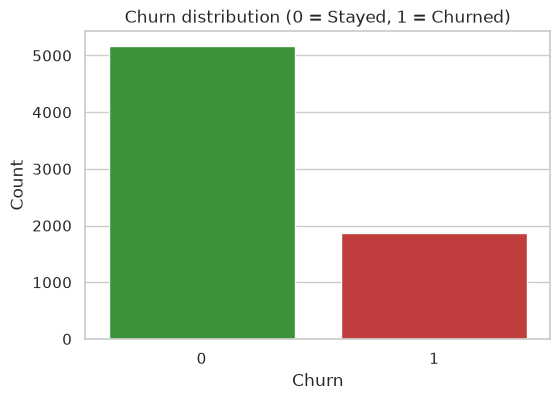

In [8]:
# Target distribution (univariate)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette=['#2ca02c', '#d62728'], legend=False)
plt.title('Churn distribution (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

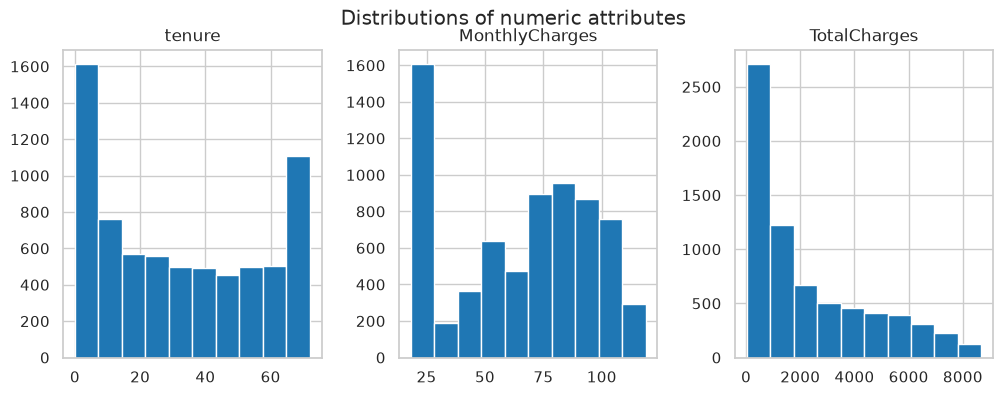

In [9]:
# Distributions of the numeric attributes (univariate)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols].hist(figsize=(12, 4), layout=(1, 3), color='#1f77b4', edgecolor='white')
plt.suptitle('Distributions of numeric attributes')
plt.show()

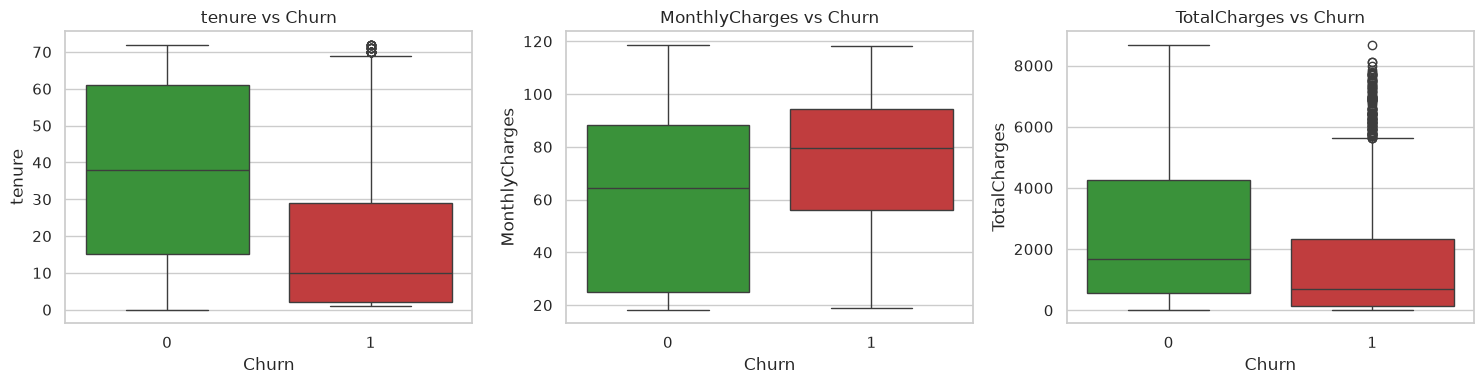

In [10]:
# Numeric attributes vs Churn (bivariate)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, hue='Churn',
                palette=['#2ca02c', '#d62728'], legend=False, ax=ax)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

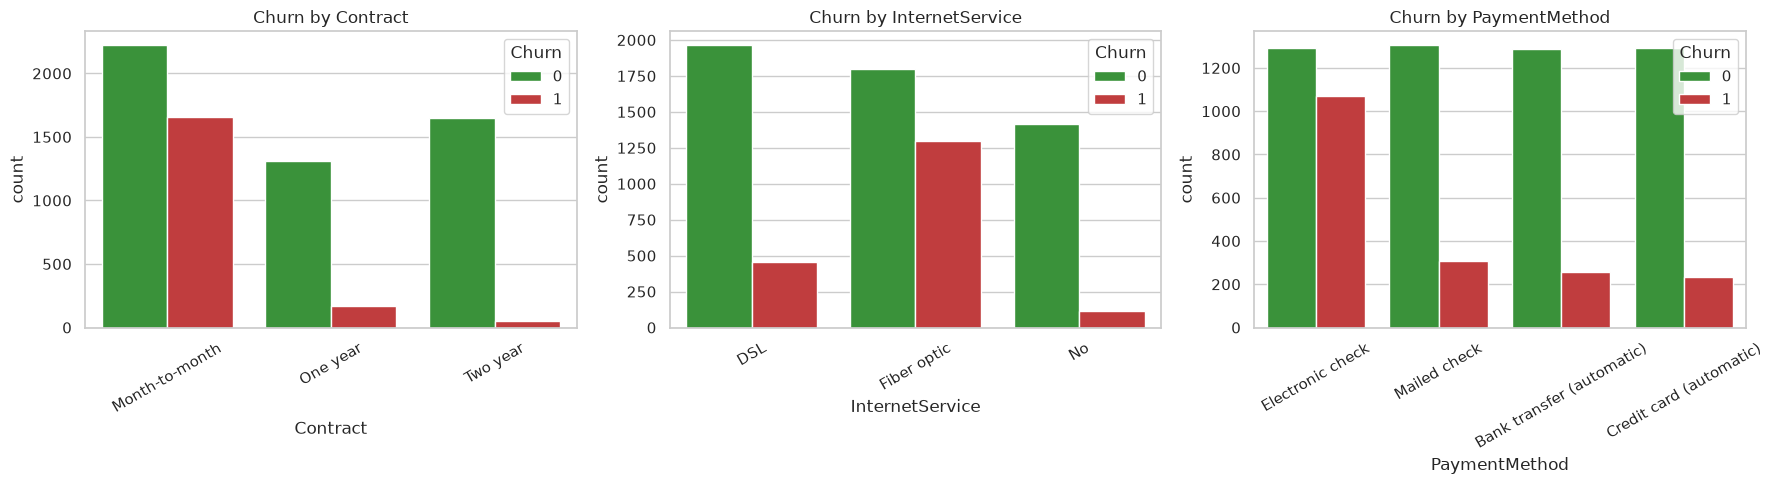

In [11]:
# Churn across key categorical attributes (bivariate)
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, palette=['#2ca02c', '#d62728'], ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

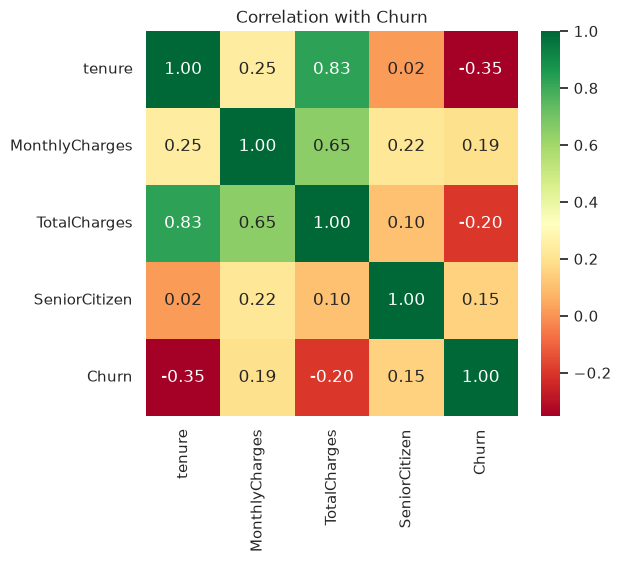

In [12]:
# Correlation of numeric attributes with Churn (multivariate)
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols + ['SeniorCitizen', 'Churn']].corr(),
            annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation with Churn')
plt.show()

## Step 6: Model building — split first, then one `Pipeline`

**Anti-pattern avoided:** do **not** `pd.get_dummies` before the split or fit a `StandardScaler` outside the model. That leaks category structure / scale into the test fold and breaks CV.

Instead:
1. Stratified train/test split on the cleaned frame
2. Put imputer + `StandardScaler` + `OneHotEncoder` + classifier inside **one** sklearn `Pipeline`


In [13]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features / target from the cleaned frame (no get_dummies)
X = df.drop(columns=['Churn'])
y = df['Churn']

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

def build_preprocess():
    numeric = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric, num_cols),
        ('cat', categorical, cat_cols),
    ])

def make_pipeline(estimator):
    """Imputer + scaler + encoder + classifier in one Pipeline."""
    return Pipeline([
        ('preprocess', build_preprocess()),
        ('model', estimator),
    ])

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Numeric:', num_cols)
print('Categorical count:', len(cat_cols))


Train: (4930, 19) | Test: (2113, 19)
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical count: 15


## Step 7: Logistic Regression (baseline inside the Pipeline)

Train a baseline classifier through the Pipeline and evaluate with a confusion matrix and accuracy.


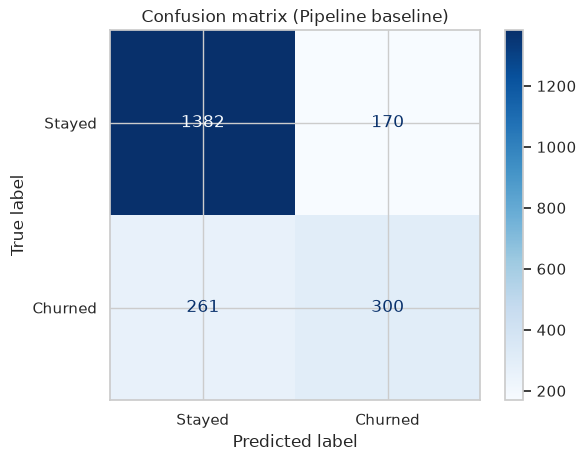

Accuracy: 79.60%


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

logreg = make_pipeline(LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=['Stayed', 'Churned']
).plot(cmap='Blues')
plt.title('Confusion matrix (Pipeline baseline)')
plt.show()

print('Accuracy: {:.2%}'.format(accuracy_score(y_test, y_pred)))


## Step 8: Beyond accuracy — precision, recall & ROC-AUC

Accuracy is misleading on an imbalanced target (~26% churn). We add a classification report and ROC-AUC, and re-fit logistic regression with `class_weight='balanced'` (still inside the Pipeline) so it catches more churners.


In [15]:
from sklearn.metrics import classification_report, roc_auc_score

# Balanced logistic regression to counter the class imbalance — still inside the Pipeline
logreg_bal = make_pipeline(LogisticRegression(max_iter=1000, class_weight='balanced'))
logreg_bal.fit(X_train, y_train)
y_pred_bal = logreg_bal.predict(X_test)
y_proba_bal = logreg_bal.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_bal, target_names=['Stayed', 'Churned']))
print('ROC-AUC: {:.3f}'.format(roc_auc_score(y_test, y_proba_bal)))


              precision    recall  f1-score   support

      Stayed       0.91      0.73      0.81      1552
     Churned       0.52      0.81      0.63       561

    accuracy                           0.75      2113
   macro avg       0.72      0.77      0.72      2113
weighted avg       0.81      0.75      0.76      2113

ROC-AUC: 0.846


## Step 9: Compare models (each wrapped in the Pipeline)

Compare logistic regression with tree-based models on **ROC-AUC**. Every model uses the same preprocess Pipeline — no external scaler or one-hot.


In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}

results = []
for name, estimator in models.items():
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df


,model,accuracy,roc_auc
2,Gradient Boosting,0.800757,0.847576
0,Logistic Regression,0.751065,0.845518
1,Random Forest,0.773781,0.827249


## Step 10: What drives churn? (feature importance via Pipeline)

Fit a Random Forest through the Pipeline and read importances from the encoded feature names the preprocessor produces.


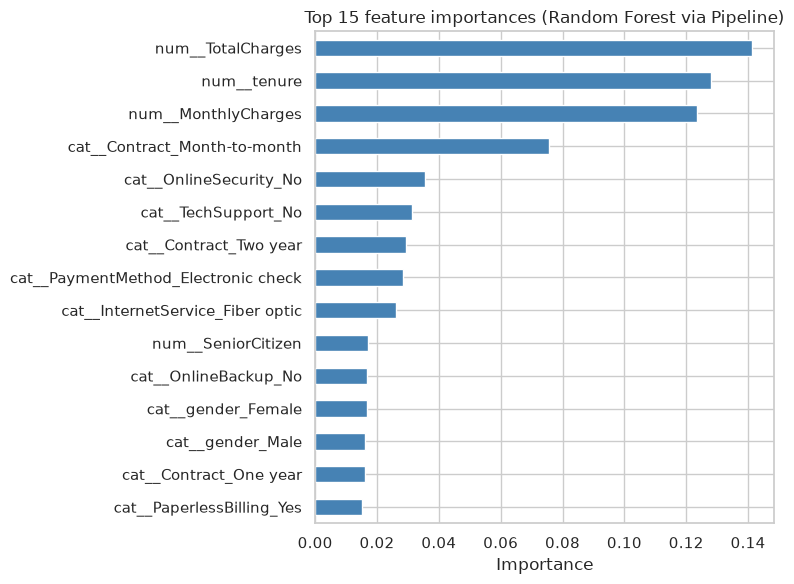

num__TotalCharges                      0.141310
num__tenure                            0.127908
num__MonthlyCharges                    0.123363
cat__Contract_Month-to-month           0.075687
cat__OnlineSecurity_No                 0.035547
cat__TechSupport_No                    0.031378
cat__Contract_Two year                 0.029271
cat__PaymentMethod_Electronic check    0.028303
cat__InternetService_Fiber optic       0.026185
num__SeniorCitizen                     0.017091
cat__OnlineBackup_No                   0.016829
cat__gender_Female                     0.016669
cat__gender_Male                       0.016231
cat__Contract_One year                 0.016162
cat__PaperlessBilling_Yes              0.015007
dtype: float64

In [17]:
rf_pipe = make_pipeline(
    RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0)
)
rf_pipe.fit(X_train, y_train)

# Recover feature names after ColumnTransformer one-hot
preprocess = rf_pipe.named_steps['preprocess']
feat_names = preprocess.get_feature_names_out()
importances = (
    pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
importances.iloc[::-1].plot(kind='barh', color='steelblue')
plt.title('Top 15 feature importances (Random Forest via Pipeline)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances


## Step 11: Hyperparameter search on the Pipeline

The model comparison picked **Gradient Boosting** as the strongest classifier, so we tune `GradientBoostingClassifier` **as the last step of the Pipeline**. Search with `model__*` prefixes so preprocess stays fixed inside every CV fold.

**Scoring — the business priority, not the sklearn default.** StreamLoop wants to *rank customers by churn risk* so retention offers reach the right people. On an imbalanced target (~26.5% churn) plain **accuracy is misleading**, so we optimise **ROC-AUC** (how well the model ranks churners above non-churners, independent of threshold) instead of the default.

**Approach:** a broad `RandomizedSearchCV` first, then a focused `GridSearchCV` around the winning region. Both use 5-fold cross-validation on **train only**, `n_jobs=1`, and `refit=True`. Baseline defaults are scored on the test set **once before** search. After the grid, we inspect `cv_results_` **mean and fold std** and document any mean-vs-stability trade-off before the final test score.


In [18]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline score once before search (test touched #1)
baseline_pipe = make_pipeline(GradientBoostingClassifier(random_state=0))
baseline_pipe.fit(X_train, y_train)
baseline_pred = baseline_pipe.predict(X_test)
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_metrics = {
    'accuracy': round(accuracy_score(y_test, baseline_pred), 4),
    'precision': round(precision_score(y_test, baseline_pred), 4),
    'recall': round(recall_score(y_test, baseline_pred), 4),
    'f1': round(f1_score(y_test, baseline_pred), 4),
    'roc_auc': round(roc_auc_score(y_test, baseline_proba), 4),
}
print('Baseline (defaults) on test — logged before search:', baseline_metrics)

# Search space — only GradientBoosting params, prefixed for the Pipeline
random_space = {
    'model__n_estimators': randint(100, 350),
    'model__learning_rate': loguniform(1e-2, 3e-1),
    'model__max_depth': randint(2, 5),
    'model__min_samples_leaf': randint(1, 30),
    'model__subsample': [0.7, 0.9, 1.0],
    'model__max_features': ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(
    make_pipeline(GradientBoostingClassifier(random_state=0)),
    param_distributions=random_space,
    n_iter=20,
    scoring='roc_auc',   # business priority (rank churn risk), not the default accuracy
    cv=5,
    n_jobs=1,
    random_state=0,
    refit=True,
)
random_search.fit(X_train, y_train)  # train only

print('RandomizedSearchCV best ROC-AUC (CV): {:.4f}'.format(random_search.best_score_))
print('Best params:', random_search.best_params_)


Baseline (defaults) on test — logged before search: {'accuracy': 0.8008, 'precision': 0.6628, 'recall': 0.508, 'f1': 0.5752, 'roc_auc': 0.8476}


RandomizedSearchCV best ROC-AUC (CV): 0.8489
Best params: {'model__learning_rate': np.float64(0.0589974509393851), 'model__max_depth': 2, 'model__max_features': None, 'model__min_samples_leaf': 12, 'model__n_estimators': 214, 'model__subsample': 0.7}


In [19]:
# Narrow around the random-search winner, then refine with GridSearchCV
best = random_search.best_params_
grid_space = {
    'model__n_estimators': sorted({
        max(50, best['model__n_estimators'] - 75),
        best['model__n_estimators'],
        best['model__n_estimators'] + 75,
    }),
    'model__learning_rate': sorted({
        round(best['model__learning_rate'] / 2, 4),
        round(best['model__learning_rate'], 4),
        round(best['model__learning_rate'] * 2, 4),
    }),
    'model__max_depth': sorted({
        max(2, best['model__max_depth'] - 1),
        best['model__max_depth'],
        best['model__max_depth'] + 1,
    }),
    'model__min_samples_leaf': [best['model__min_samples_leaf']],
    'model__subsample': [best['model__subsample']],
    'model__max_features': [best['model__max_features']],
}

grid_search = GridSearchCV(
    make_pipeline(GradientBoostingClassifier(random_state=0)),
    param_grid=grid_space,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,
    refit=True,
)
grid_search.fit(X_train, y_train)  # train only

print('GridSearchCV best mean CV ROC-AUC: {:.4f}'.format(grid_search.best_score_))
print('Face-value best_params_:', grid_search.best_params_)


GridSearchCV best mean CV ROC-AUC: 0.8489
Face-value best_params_: {'model__learning_rate': np.float64(0.059), 'model__max_depth': 2, 'model__max_features': None, 'model__min_samples_leaf': 12, 'model__n_estimators': 214, 'model__subsample': 0.7}


In [20]:
# Stability review: inspect cv_results_ mean AND fold std (not face-value best_params_ alone)
cvres = grid_search.cv_results_
rows = []
for i in range(len(cvres['mean_test_score'])):
    rows.append({
        'rank': int(cvres['rank_test_score'][i]),
        'mean_roc_auc': float(cvres['mean_test_score'][i]),
        'std': float(cvres['std_test_score'][i]),
        'mean_minus_std': float(cvres['mean_test_score'][i] - cvres['std_test_score'][i]),
        **{k.replace('param_', ''): cvres[k][i] for k in cvres if k.startswith('param_')},
    })
top = (
    pd.DataFrame(rows)
    .sort_values(['mean_roc_auc', 'mean_minus_std'], ascending=False)
    .head(8)
    .reset_index(drop=True)
)
print('Top GridSearchCV candidates (mean ROC-AUC vs fold std):')
print(top.to_string(index=False))

# Trade-off rule: prefer slightly lower mean when std drops ≥25% and ≥0.005 abs within 0.01 mean window
face = top.iloc[0]
chosen = face
selection_reason = (
    'Kept highest mean CV ROC-AUC ({:.4f} ± {:.4f}); '
    'no nearby candidate offered a clear stability trade-off.'
).format(face['mean_roc_auc'], face['std'])

for _, cand in top.iloc[1:].iterrows():
    mean_drop = face['mean_roc_auc'] - cand['mean_roc_auc']
    std_drop = face['std'] - cand['std']
    if mean_drop <= 0.01 and std_drop >= 0.005 and cand['std'] <= face['std'] * 0.75:
        chosen = cand
        selection_reason = (
            'Chose a slightly lower mean CV ROC-AUC ({:.4f} vs leader {:.4f}) '
            'because fold std fell from {:.4f} to {:.4f}. A more stable ranking '
            'quality across folds is preferable to chasing the peak mean.'
        ).format(cand['mean_roc_auc'], face['mean_roc_auc'], face['std'], cand['std'])
        break

print()
print('Final model choice:')
print(' ', selection_reason)


Top GridSearchCV candidates (mean ROC-AUC vs fold std):
 rank  mean_roc_auc      std  mean_minus_std  model__learning_rate  model__max_depth model__max_features  model__min_samples_leaf  model__n_estimators  model__subsample
    1      0.848898 0.015933        0.832966                0.0590                 2                None                       12                  214               0.7
    2      0.848548 0.016926        0.831622                0.0590                 2                None                       12                  139               0.7
    3      0.848479 0.015633        0.832845                0.0590                 2                None                       12                  289               0.7
    4      0.848122 0.015754        0.832368                0.0295                 3                None                       12                  214               0.7
    5      0.847778 0.016555        0.831223                0.0295                 3               

In [21]:
# Final test score once (test touched #2) after CV stability review
param_keys = [c for c in top.columns if c.startswith('model__')]
chosen_params = {k: chosen[k] for k in param_keys}
face_params = {k: face[k] for k in param_keys}

if chosen_params != face_params:
    best_model = make_pipeline(GradientBoostingClassifier(random_state=0))
    best_model.set_params(**chosen_params)
    best_model.fit(X_train, y_train)
else:
    best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'accuracy': round(accuracy_score(y_test, y_pred_tuned), 4),
    'precision': round(precision_score(y_test, y_pred_tuned), 4),
    'recall': round(recall_score(y_test, y_pred_tuned), 4),
    'f1': round(f1_score(y_test, y_pred_tuned), 4),
    'roc_auc': round(roc_auc_score(y_test, y_proba_tuned), 4),
}

print('Tuned Pipeline Gradient Boosting on the test set:')
for k, v in tuned_metrics.items():
    print('  {:10s}: {:.4f}'.format(k, v))
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Churned']))
print('Final params:', chosen_params)
print()
print('Baseline vs tuned trade-off (test):')
print(pd.DataFrame([baseline_metrics, tuned_metrics], index=['baseline', 'tuned']))
print()
print(
    'Trade-off note: ROC-AUC search targets ranking quality for retention outreach. '
    'Accuracy/precision may move little or even dip if the model ranks churn risk '
    'better without changing the default 0.5 threshold much — that is expected and '
    'why accuracy was not the search objective.'
)


Tuned Pipeline Gradient Boosting on the test set:
  accuracy  : 0.8050
  precision : 0.6659
  recall    : 0.5330
  f1        : 0.5921
  roc_auc   : 0.8499

              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1552
     Churned       0.67      0.53      0.59       561

    accuracy                           0.81      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.80      0.81      0.80      2113

Final params: {'model__learning_rate': np.float64(0.059), 'model__max_depth': np.int64(2), 'model__max_features': None, 'model__min_samples_leaf': np.int64(12), 'model__n_estimators': np.int64(214), 'model__subsample': np.float64(0.7)}

Baseline vs tuned trade-off (test):
          accuracy  precision  recall      f1  roc_auc
baseline    0.8008     0.6628   0.508  0.5752   0.8476
tuned       0.8050     0.6659   0.533  0.5921   0.8499

Trade-off note: ROC-AUC search targets ranking quality for retention outreach.

## Conclusion

- Preprocessing (`SimpleImputer` → `StandardScaler` / `OneHotEncoder`) lives **inside** one sklearn `Pipeline` with the classifier — no `get_dummies` before the split and no scaler fit outside CV.
- The dataset is **imbalanced** (~26.5% churn), so **accuracy alone is misleading**; we optimise **ROC-AUC** (rank churn risk for retention) and still report precision/recall/F1.
- **Baseline** defaults are logged on the test set **before** search; `RandomizedSearchCV` → `GridSearchCV` run on **train only**.
- We inspected `cv_results_` **mean and fold std**, documented any mean-vs-stability trade-off, then scored the holdout **once** with the final Pipeline.
- **So what for StreamLoop:** prioritize retention offers for **low-tenure, month-to-month, high-monthly-charge** customers; longer contracts remain the strongest churn reducer.
